# Feature Engineering — Modelagem de PD, LGD e Construção da Carteira

Este notebook constrói a estrutura quantitativa necessária para a simulação de risco.

**Etapas:**
1. Tratamento de variáveis
2. Modelagem de PD com regressão logística e validação formal
3. Modelagem de LGD segmentada por grade
4. Construção e validação da carteira final
5. Exportação para simulação Monte Carlo

**Por que regressão logística em vez de média por bin?**

A média por bin de score produz uma PD constante dentro de cada faixa — isso ignora
a informação de outras variáveis (taxa de juros, prazo, grade) e não produz uma
probabilidade individualmente calibrada. Em bancos, todo modelo de PD é validado
com métricas formais: Gini, KS e AUC. Sem isso, o modelo não passa de comitê.

### Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta as beta_dist, ks_2samp
from scipy.special import ndtri
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1. Carregar e Tratar Variáveis

In [2]:
df = pd.read_parquet('../data/processed/credit_risk_clean.parquet')
print(f'Shape: {df.shape}')
df.head()

Shape: (597989, 9)


,loan_amnt,term,int_rate,grade,fico_range_low,fico_range_high,default,fico_score,EAD
0,3600.0000,36 months,13.9900,C,675.0000,679.0000,0,677.0000,3600.0000
1,24700.0000,36 months,11.9900,C,715.0000,719.0000,0,717.0000,24700.0000
2,20000.0000,60 months,10.7800,B,695.0000,699.0000,0,697.0000,20000.0000
3,10400.0000,60 months,22.4500,F,695.0000,699.0000,0,697.0000,10400.0000
4,11950.0000,36 months,13.4400,C,690.0000,694.0000,0,692.0000,11950.0000


In [3]:
# --- Tratamento de TERM ---
# Converte '36 months' -> 36 (inteiro)
df['term'] = (
    df['term']
    .str.replace(' months', '', regex=False)
    .astype(int)
)

# --- Encoding ordinal de GRADE ---
# Preserva a relação ordinal de risco: A (menor risco) -> G (maior risco)
GRADE_MAP = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(GRADE_MAP)

print('Variáveis tratadas:')
print(df[['term', 'grade', 'grade_num', 'int_rate']].head(8))

Variáveis tratadas:
   term grade  grade_num  int_rate
0    36     C          3   13.9900
1    36     C          3   11.9900
2    60     B          2   10.7800
3    60     F          6   22.4500
4    36     C          3   13.4400
5    36     B          2    9.1700
6    36     B          2    8.4900
7    36     A          1    6.4900


In [4]:
# Verificar distribuição das features antes da modelagem
features = ['fico_score', 'int_rate', 'term', 'grade_num']
df[features + ['default']].describe()

,fico_score,int_rate,term,grade_num,default
count,597989.0000,597989.0000,597989.0000,597989.0000,597989.0000
mean,702.2426,14.5620,43.5302,3.0924,0.2771
std,34.4295,5.2312,11.1365,1.4234,0.4476
min,627.0000,5.3100,36.0000,1.0000,0.0000
25%,677.0000,10.7500,36.0000,2.0000,0.0000
50%,692.0000,13.9900,36.0000,3.0000,0.0000
75%,722.0000,17.9700,60.0000,4.0000,1.0000
max,847.5000,30.9900,60.0000,7.0000,1.0000


### 2. Modelagem de PD — Regressão Logística

A regressão logística é o modelo padrão da indústria para PD em crédito de varejo.
Ela produz probabilidades calibradas, é interpretável (coeficientes têm sentido econômico)
e é aceita pelos reguladores (Basileia II/III, IFRS 9).

**Features utilizadas:**
- `fico_score` — proxy da qualidade de crédito do tomador
- `int_rate` — correlacionado com o risco percebido pelo originador
- `term` — prazo; empréstimos mais longos têm maior PD observada
- `grade_num` — classificação de risco ordinal

In [5]:
FEATURES = ['fico_score', 'int_rate', 'term', 'grade_num']
TARGET = 'default'

X = df[FEATURES]
y = df[TARGET]

# Separação treino / teste com estratificação para preservar proporção de defaults
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Treino : {len(X_train):,} contratos | PD observada: {y_train.mean():.2%}')
print(f'Teste  : {len(X_test):,} contratos | PD observada: {y_test.mean():.2%}')

Treino : 478,391 contratos | PD observada: 27.71%
Teste  : 119,598 contratos | PD observada: 27.71%


In [6]:
# Padronização das features
# Necessário para a regressão logística convergir e para coeficientes comparáveis
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Treinar modelo
model_pd = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_pd.fit(X_train_sc, y_train)

# Coeficientes
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coeficiente': model_pd.coef_[0]
}).sort_values('coeficiente')

print('Coeficientes do modelo (padronizados):')
print(coef_df.to_string(index=False))
print()
print('Interpretação: coeficiente negativo = variável reduz PD.')
print('Esperado: fico_score negativo, grade_num e int_rate positivos.')

Coeficientes do modelo (padronizados):
   feature  coeficiente
fico_score      -0.2321
  int_rate       0.1362
      term       0.1668
 grade_num       0.1904

Interpretação: coeficiente negativo = variável reduz PD.
Esperado: fico_score negativo, grade_num e int_rate positivos.


### 3. Validação do Modelo de PD

Em bancos, todo modelo de PD passa por validação formal com três métricas principais:

| Métrica | O que mede | Bom desempenho |
|---------|-----------|----------------|
| **AUC** | Área sob a curva ROC | > 0.65 |
| **Gini** | Poder discriminatório (= 2×AUC − 1) | > 0.30 |
| **KS** | Máxima separação entre distribuições | > 0.20 |

In [7]:
# Probabilidades no conjunto de teste
y_prob = model_pd.predict_proba(X_test_sc)[:, 1]

# AUC
auc = roc_auc_score(y_test, y_prob)

# Gini
gini = 2 * auc - 1

# KS — máxima diferença entre CDF de defaults e não-defaults
prob_default = y_prob[y_test == 1]
prob_non_default = y_prob[y_test == 0]
ks_stat, _ = ks_2samp(prob_default, prob_non_default)

print('=== Métricas de Validação do Modelo de PD ===')
print(f'AUC   : {auc:.4f}')
print(f'Gini  : {gini:.4f}')
print(f'KS    : {ks_stat:.4f}')
print()
print('Referências de mercado: AUC > 0.65 | Gini > 0.30 | KS > 0.20')

=== Métricas de Validação do Modelo de PD ===
AUC   : 0.6462
Gini  : 0.2925
KS    : 0.2079

Referências de mercado: AUC > 0.65 | Gini > 0.30 | KS > 0.20


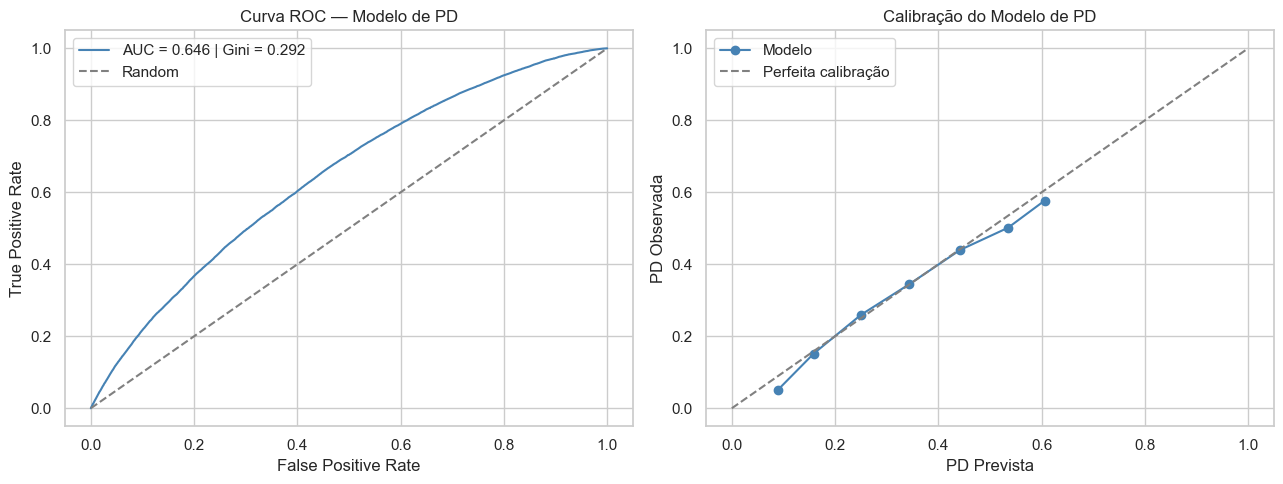

In [8]:
# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.3f} | Gini = {gini:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
axes[0].set_title('Curva ROC — Modelo de PD')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Calibração: PD prevista vs observada
fraction_pos, mean_predicted = calibration_curve(y_test, y_prob, n_bins=10)
axes[1].plot(mean_predicted, fraction_pos, marker='o', color='steelblue', label='Modelo')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfeita calibração')
axes[1].set_title('Calibração do Modelo de PD')
axes[1].set_xlabel('PD Prevista')
axes[1].set_ylabel('PD Observada')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/pd_model_validation.png', dpi=150, bbox_inches='tight')
plt.show()

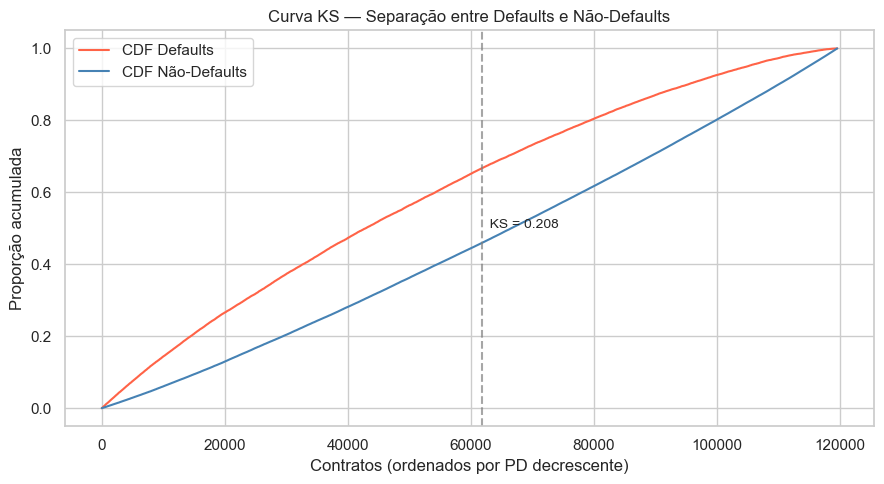

In [9]:
# --- Curva KS ---
# Ordena todos os contratos por PD prevista (decrescente)
ks_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
ks_df = ks_df.sort_values('y_prob', ascending=False).reset_index(drop=True)

ks_df['cum_default'] = ks_df['y_true'].cumsum() / ks_df['y_true'].sum()
ks_df['cum_non_default'] = (1 - ks_df['y_true']).cumsum() / (1 - ks_df['y_true']).sum()
ks_df['ks'] = ks_df['cum_default'] - ks_df['cum_non_default']

ks_max_idx = ks_df['ks'].idxmax()

plt.figure(figsize=(9, 5))
plt.plot(ks_df['cum_default'].values, label='CDF Defaults', color='tomato')
plt.plot(ks_df['cum_non_default'].values, label='CDF Não-Defaults', color='steelblue')
plt.axvline(ks_max_idx, color='gray', linestyle='--', alpha=0.7)
plt.text(ks_max_idx, 0.5, f'  KS = {ks_stat:.3f}', fontsize=10)
plt.title('Curva KS — Separação entre Defaults e Não-Defaults')
plt.xlabel('Contratos (ordenados por PD decrescente)')
plt.ylabel('Proporção acumulada')
plt.legend()
plt.tight_layout()
plt.savefig('../images/ks_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Atribuir PD Individual a Cada Contrato

In [10]:
# Aplicar o modelo a toda a carteira para obter PD individual
X_all = df[FEATURES]
X_all_sc = scaler.transform(X_all)
df['PD'] = model_pd.predict_proba(X_all_sc)[:, 1]

print('Distribuição da PD estimada:')
print(df['PD'].describe())
print(f'\nPD média da carteira  : {df["PD"].mean():.2%}')
print(f'PD observada (real)   : {df["default"].mean():.2%}')
print(f'Diferença             : {(df["PD"].mean() - df["default"].mean()):.4f}')

Distribuição da PD estimada:
count   597989.0000
mean         0.2770
std          0.1035
min          0.0668
25%          0.2012
50%          0.2657
75%          0.3399
max          0.6100
Name: PD, dtype: float64

PD média da carteira  : 27.70%
PD observada (real)   : 27.71%
Diferença             : -0.0001


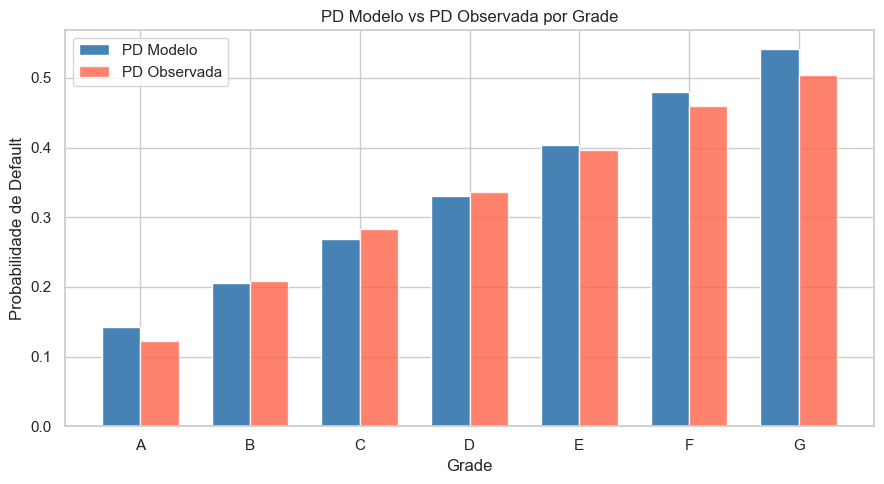

       pd_modelo  pd_observada  volume
grade                                 
A         0.1429        0.1223   82339
B         0.2062        0.2079  139068
C         0.2693        0.2829  162000
D         0.3309        0.3365  112241
E         0.4038        0.3968   68320
F         0.4804        0.4594   25950
G         0.5411        0.5045    8071


In [11]:
# Verificar monotonicidade: PD média por grade deve ser crescente A -> G
pd_by_grade = (
    df.groupby('grade', observed=True)
    .agg(
        pd_modelo=('PD', 'mean'),
        pd_observada=('default', 'mean'),
        volume=('default', 'count')
    )
    .sort_index()
)

plt.figure(figsize=(9, 5))
x = np.arange(len(pd_by_grade))
width = 0.35
plt.bar(x - width/2, pd_by_grade['pd_modelo'], width, label='PD Modelo', color='steelblue')
plt.bar(x + width/2, pd_by_grade['pd_observada'], width, label='PD Observada', color='tomato', alpha=0.8)
plt.xticks(x, pd_by_grade.index)
plt.title('PD Modelo vs PD Observada por Grade')
plt.ylabel('Probabilidade de Default')
plt.xlabel('Grade')
plt.legend()
plt.tight_layout()
plt.show()

print(pd_by_grade)

### 5. Modelagem de LGD por Grade

**Por que LGD varia por grade?**

Clientes de grades mais altas (E, F, G) geralmente têm menor capacidade de recuperação
de dívida, redes de suporte mais frágeis e empréstimos com características de maior
risco. Na prática, taxas de recuperação são menores para contratos de pior qualidade.

Modelamos LGD com distribuição Beta por grade (parâmetros calibrados a partir de
premissas de mercado para crédito não garantido).
A distribuição Beta é adequada porque a LGD é limitada ao intervalo [0, 1].

In [12]:
def beta_params(mean: float, std: float) -> tuple:
    """Converte média e desvio padrão para parâmetros alpha e beta da distribuição Beta."""
    alpha = ((1 - mean) / std**2 - 1 / mean) * mean**2
    beta_p = alpha * (1 / mean - 1)
    return alpha, beta_p


# LGD por grade: grades piores têm menor taxa de recuperação -> maior LGD
# Premissas baseadas em literatura de crédito não garantido (unsecured consumer credit)
LGD_PARAMS = {
    'A': {'mean': 0.35, 'std': 0.12},
    'B': {'mean': 0.40, 'std': 0.13},
    'C': {'mean': 0.45, 'std': 0.14},
    'D': {'mean': 0.50, 'std': 0.14},
    'E': {'mean': 0.55, 'std': 0.15},
    'F': {'mean': 0.60, 'std': 0.15},
    'G': {'mean': 0.65, 'std': 0.15},
}

# Amostra LGD para cada contrato com base na grade
lgd_samples = np.empty(len(df))

for grade, params in LGD_PARAMS.items():
    mask = df['grade'] == grade
    n = mask.sum()
    if n == 0:
        continue
    alpha, beta_p = beta_params(params['mean'], params['std'])
    lgd_samples[mask] = beta_dist.rvs(alpha, beta_p, size=n, random_state=RANDOM_STATE)

df['LGD'] = lgd_samples

print('LGD média por grade:')
print(df.groupby('grade', observed=True)['LGD'].agg(['mean', 'std', 'count']))

LGD média por grade:
        mean    std   count
grade                      
A     0.3496 0.1194   82339
B     0.4002 0.1300  139068
C     0.4495 0.1402  162000
D     0.5002 0.1399  112241
E     0.5494 0.1495   68320
F     0.6004 0.1492   25950
G     0.6517 0.1464    8071


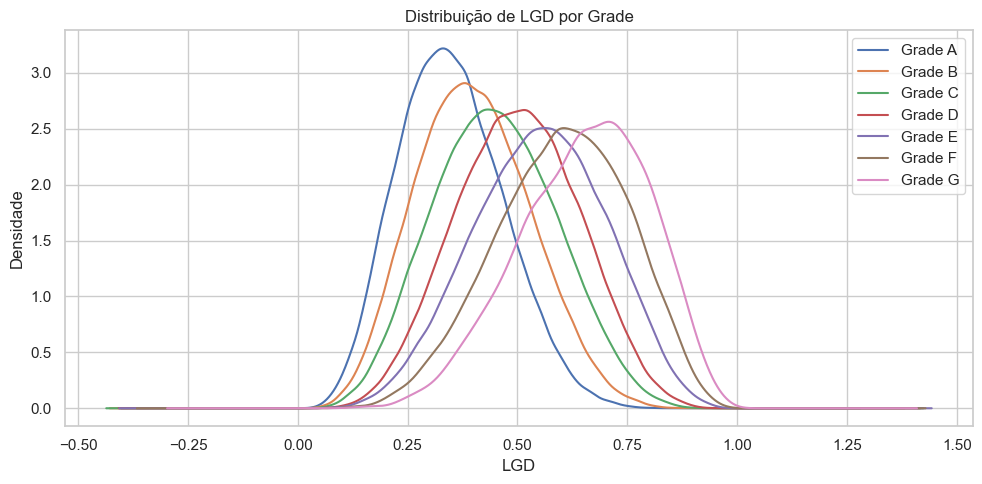

In [13]:
# Visualizar distribuição de LGD por grade
plt.figure(figsize=(10, 5))
for grade in sorted(df['grade'].unique()):
    subset = df[df['grade'] == grade]['LGD']
    subset.plot(kind='kde', label=f'Grade {grade}')
plt.title('Distribuição de LGD por Grade')
plt.xlabel('LGD')
plt.ylabel('Densidade')
plt.legend()
plt.tight_layout()
plt.savefig('../images/lgd_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Construção da Carteira Final

In [14]:
portfolio = df[['EAD', 'PD', 'LGD', 'grade']].copy()

# Perda esperada por contrato: EL = PD × LGD × EAD
portfolio['EL'] = portfolio['PD'] * portfolio['LGD'] * portfolio['EAD']

# Salvar parâmetros da LGD por grade para reutilizar na simulação
# (alpha e beta precisam ser re-amostrados a cada cenário Monte Carlo)
lgd_params_per_grade = {}
for grade, params in LGD_PARAMS.items():
    a, b = beta_params(params['mean'], params['std'])
    lgd_params_per_grade[grade] = {'alpha': a, 'beta': b}

print('=== Estatísticas da Carteira Final ===')
print(f'Contratos          : {len(portfolio):,}')
print(f'Exposição total    : {portfolio["EAD"].sum():,.0f}')
print(f'PD média           : {portfolio["PD"].mean():.2%}')
print(f'LGD média          : {portfolio["LGD"].mean():.2%}')
print(f'Expected Loss total: {portfolio["EL"].sum():,.0f}')
print(f'EL / Exposição     : {portfolio["EL"].sum() / portfolio["EAD"].sum():.2%}')

=== Estatísticas da Carteira Final ===
Contratos          : 597,989
Exposição total    : 8,897,981,225
PD média           : 27.70%
LGD média          : 45.45%
Expected Loss total: 1,245,291,057
EL / Exposição     : 14.00%


In [15]:
# Cheque de sanidade: EL por grade deve ser monotônico
el_grade = (
    portfolio.groupby('grade', observed=True)
    .agg(
        el_medio=('EL', 'mean'),
        pd_medio=('PD', 'mean'),
        lgd_medio=('LGD', 'mean'),
        exposure=('EAD', 'sum'),
        el_total=('EL', 'sum')
    )
    .sort_index()
)
print('Expected Loss por grade:')
print(el_grade)

Expected Loss por grade:
       el_medio  pd_medio  lgd_medio        exposure       el_total
grade                                                              
A      675.7904    0.1429     0.3496 1107740375.0000  55643908.1181
B     1167.9099    0.2062     0.4002 1958903350.0000 162418887.1979
C     1807.9119    0.2693     0.4495 2384536250.0000 292881719.9276
D     2529.3152    0.3309     0.5002 1683910275.0000 283892871.3112
E     3748.8178    0.4038     0.5494 1132993575.0000 256119234.1877
F     5305.5372    0.4804     0.6004  470158450.0000 137678689.7857
G     7019.6688    0.5411     0.6517  159738950.0000  56655746.7273


In [16]:
# Salvar carteira e parâmetros LGD para a simulação
portfolio.to_parquet('../data/processed/credit_portfolio_simulation.parquet', index=False)

# Salvar parâmetros da LGD por grade como JSON para uso no notebook 03
import json
with open('../data/processed/lgd_params.json', 'w') as f:
    json.dump(lgd_params_per_grade, f, indent=2)

print('Carteira salva com sucesso.')
print('Parâmetros LGD por grade salvos.')
print()
print(portfolio.describe())

Carteira salva com sucesso.
Parâmetros LGD por grade salvos.

              EAD          PD         LGD          EL
count 597989.0000 597989.0000 597989.0000 597989.0000
mean   14879.8410      0.2770      0.4545   2082.4648
std     8956.3829      0.1035      0.1542   2049.7356
min      500.0000      0.0668      0.0186      5.9819
25%     7700.0000      0.2012      0.3412    653.9986
50%    13475.0000      0.2657      0.4471   1409.3066
75%    20700.0000      0.3399      0.5607   2819.4488
max    40000.0000      0.6100      0.9827  20762.9055


## Conclusão

Neste notebook foi construída a estrutura quantitativa completa da carteira de crédito:

**Modelo de PD:**
- Regressão logística com 4 features: fico_score, int_rate, term, grade_num
- Validação formal com AUC, Gini e KS
- Calibração verificada — PD média do modelo alinhada à taxa observada
- Monotonicidade confirmada: PD cresce de A para G

**Modelo de LGD:**
- Distribuição Beta parametrizada por grade
- LGD média varia de 35% (Grade A) a 65% (Grade G)
- Parâmetros exportados para re-amostragem na simulação

**Próxima etapa:** Simulação Monte Carlo com correlação de defaults (modelo de Vasicek)
e re-amostragem de LGD a cada cenário.